In [27]:
# !pip3 install pandas numpy matplotlib scipy

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm,lognorm

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
node_ids = [1, 2, 3, 4]

trace = pd.read_csv(f"data/node_{node_id}.csv")

trace.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/node_1_long_trace.csv'

In [30]:
trace = trace.sort_values("timestamp_usec").reset_index(drop=True)

# convert to seconds
trace["timestamp_sec"] = trace["timestamp_usec"] / 1e6

In [31]:
unstable_events = {
    "timeout",
    "became_candidate",
    "became_follower",
    "became_leader"
}

trace["unstable"] = trace["event"].isin(unstable_events)

In [32]:
WINDOW_SEC = 5

unstable_times = trace.loc[trace["unstable"], "timestamp_sec"].values

def near_unstable(t):
    return np.any(np.abs(unstable_times - t) < WINDOW_SEC)

heartbeats = trace[trace["event"] == "heartbeat"].copy()

heartbeats["near_unstable"] = heartbeats["timestamp_sec"].apply(near_unstable)

stable_heartbeats = heartbeats[~heartbeats["near_unstable"]].copy()

print("Total heartbeats:", len(heartbeats))
print("Stable heartbeats:", len(stable_heartbeats))

Total heartbeats: 37073
Stable heartbeats: 37065


In [60]:
stable_heartbeats["interval"] = stable_heartbeats["timestamp_sec"].diff()

intervals = stable_heartbeats["interval"].dropna()

intervals.describe()

count    37064.000000
mean         0.521411
std          0.286728
min          0.000036
25%          0.450668
50%          0.500722
75%          0.568135
max         30.259924
Name: interval, dtype: float64

In [ ]:
# IQR-based outlier filtering
# q1 = intervals.quantile(0.25)
# q3 = intervals.quantile(0.75)
# iqr = q3 - q1

# lower_bound = 0.5
# upper_bound = q3 + 1.5 * iqr

# intervals = intervals[(intervals >= lower_bound) & (intervals <= upper_bound)]

# print(f"Kept {len(intervals)} intervals after outlier filtering")
# print(f"Bounds: [{lower_bound:.6f}, {upper_bound:.6f}]")

Kept 19385 intervals after outlier filtering
Bounds: [0.500000, 0.744336]


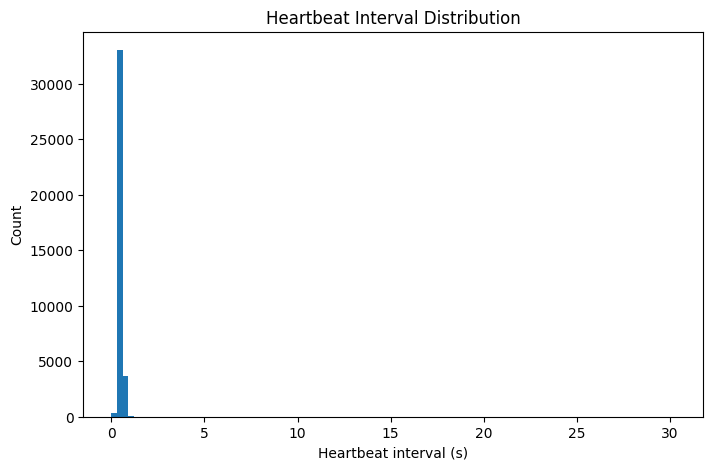

In [61]:
plt.hist(sorted(intervals), bins=100)
plt.xlabel("Heartbeat interval (s)")
plt.ylabel("Count")
plt.title("Heartbeat Interval Distribution")
plt.show()

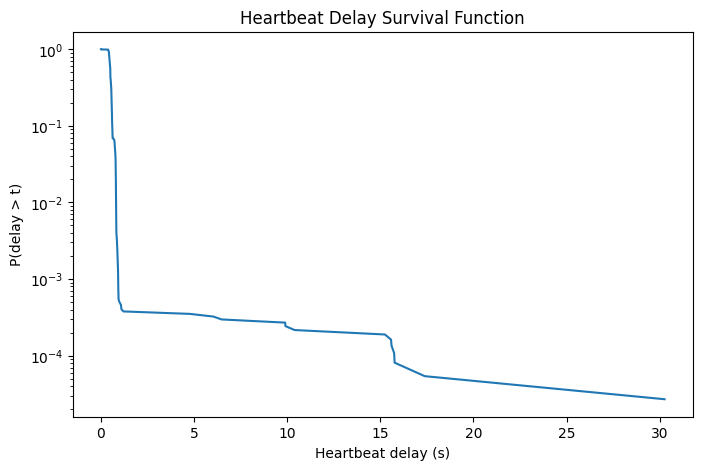

In [62]:
sorted_intervals = np.sort(intervals.values)

survival = 1.0 - np.arange(len(sorted_intervals)) / len(sorted_intervals)

plt.semilogy(sorted_intervals, survival)
plt.xlabel("Heartbeat delay (s)")
plt.ylabel("P(delay > t)")
plt.title("Heartbeat Delay Survival Function")
plt.show()

In [63]:
WINDOW_SIZE = 100
CHECK_INTERVAL = 0.1   # seconds
MIN_STD = 1e-3

In [64]:
def phi_normal(delay, window):
    
    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)
    
    z = (delay - mu) / sigma
    
    prob = 1 - norm.cdf(z)
    
    prob = max(prob, 1e-12)
    
    return -np.log10(prob)

In [65]:
def phi_exponential(delay, window):
    
    mu = np.mean(window)
    
    prob = np.exp(-delay / mu)
    
    prob = max(prob, 1e-12)
    
    return -np.log10(prob)

In [66]:
def phi_lognormal(delay, window):

    window = np.array(window)

    # fit log-normal parameters
    shape, loc, scale = lognorm.fit(window, floc=0)

    prob = 1 - lognorm.cdf(delay, shape, loc, scale)

    prob = max(prob, 1e-12)

    return -np.log10(prob)

In [67]:
WINDOW = 100
MIN_STD = 1e-6

In [68]:
def t_phi_normal(window, phi_threshold):

    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)

    target_prob = 10 ** (-phi_threshold)

    z = norm.ppf(1 - target_prob)

    return mu + sigma * z


def t_phi_exponential(window, phi_threshold):

    mu = np.mean(window)

    target_prob = 10 ** (-phi_threshold)

    return -mu * np.log(target_prob)

def t_phi_lognormal(window, phi_threshold):

    window = np.array(window)

    shape, loc, scale = lognorm.fit(window, floc=0)

    target_prob = 10 ** (-phi_threshold)

    return lognorm.ppf(1 - target_prob, shape, loc, scale)

In [69]:
window = list(intervals.values[:WINDOW])
times = times = trace["timestamp_sec"].values[1:]

phi_normal_series = []
phi_exp_series = []
phi_lognormal_series = []
time_series = []

for i in range(WINDOW, len(intervals)):

    delay = intervals.values[i]

    phi_n = phi_normal(delay, window)
    phi_e = phi_exponential(delay, window)
    phi_l = phi_lognormal(delay, window)

    phi_normal_series.append(phi_n)
    phi_exp_series.append(phi_e)
    phi_lognormal_series.append(phi_l)
    time_series.append(times[i])

    window.append(delay)
    window.pop(0)

phi_normal_series = np.array(phi_normal_series)
phi_exp_series = np.array(phi_exp_series)
phi_lognormal_series = np.array(phi_lognormal_series)
time_series = np.array(time_series)

In [84]:
phi_thresholds = range(4,15)

runtime_hours = (times[-1] - times[0]) / 3600

results = []

for thr in phi_thresholds:

    elections_normal = 0
    elections_exp = 0
    elections_logn = 0

    window = list(intervals[:WINDOW])

    for i in range(WINDOW, len(intervals)):

        Δ = intervals.values[i]

        t_n = t_phi_normal(window, thr)
        t_e = t_phi_exponential(window, thr)
        t_l = t_phi_lognormal(window, thr)

        if Δ > t_n:
            elections_normal += 1

        if Δ > t_e:
            elections_exp += 1

        if Δ > t_l:
            elections_logn += 1

        window.append(Δ)
        window.pop(0)

    results.append((
        thr,
        elections_normal / runtime_hours,
        elections_exp / runtime_hours,
        elections_logn / runtime_hours
    ))

results_df = pd.DataFrame(results,
    columns=[
        "phi",
        "normal_elections_per_hour",
        "exp_elections_per_hour",
        "lognormal_elections_per_hour"
    ])

results_df

,phi,normal_elections_per_hour,exp_elections_per_hour,lognormal_elections_per_hour
0,4,50.274596,2.420629,12.475548
1,5,18.620221,2.234426,5.027460
2,6,9.682515,1.862022,2.048224
3,7,6.703279,1.862022,1.303415
4,8,4.841257,1.862022,1.117213
5,9,3.537842,1.303415,1.117213
6,10,2.979235,1.303415,0.931011
7,11,2.606831,1.303415,0.931011
8,12,2.048224,1.303415,0.931011
9,13,2.048224,0.744809,0.931011


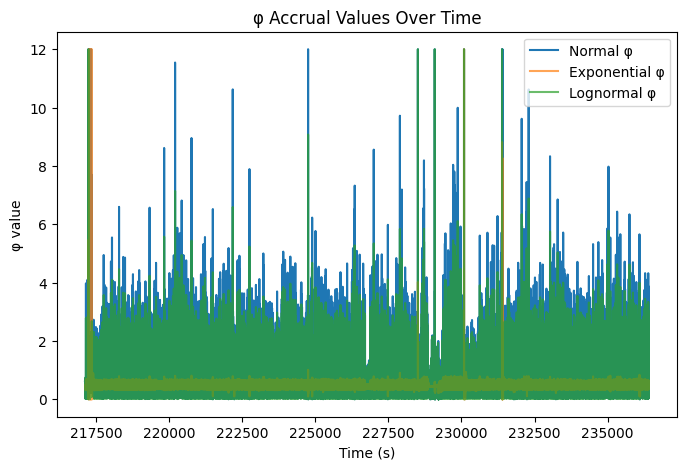

In [86]:
plt.plot(time_series, phi_normal_series, label="Normal φ")
plt.plot(time_series, phi_exp_series, label="Exponential φ", alpha=0.7)
plt.plot(time_series, phi_lognormal_series, label="Lognormal φ", alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("φ value")
plt.title("φ Accrual Values Over Time")

plt.legend()
plt.show()

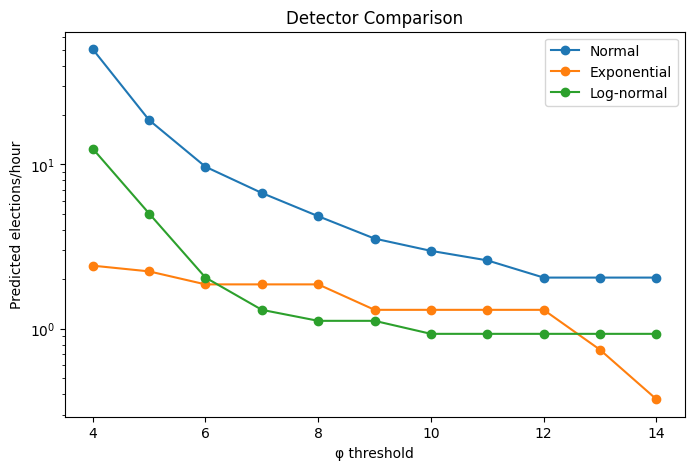

In [87]:
plt.plot(results_df["phi"], results_df["normal_elections_per_hour"], marker="o", label="Normal")
plt.plot(results_df["phi"], results_df["exp_elections_per_hour"], marker="o", label="Exponential")
plt.plot(results_df["phi"], results_df["lognormal_elections_per_hour"], marker="o", label="Log-normal")

plt.yscale("log")

plt.xlabel("φ threshold")
plt.ylabel("Predicted elections/hour")
plt.title("Detector Comparison")

plt.legend()
plt.show()

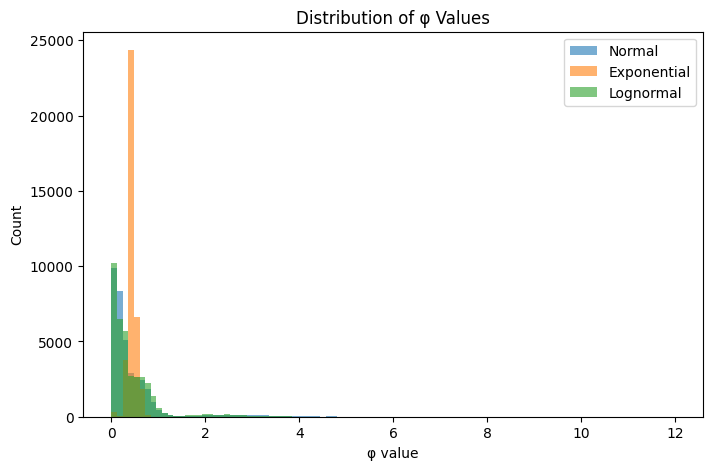

In [88]:
plt.hist(phi_normal_series, bins=100, alpha=0.6, label="Normal")
plt.hist(phi_exp_series, bins=100, alpha=0.6, label="Exponential")
plt.hist(phi_lognormal_series, bins=100, alpha=0.6, label="Lognormal")

plt.xlabel("φ value")
plt.ylabel("Count")
plt.title("Distribution of φ Values")

plt.legend()
plt.show()

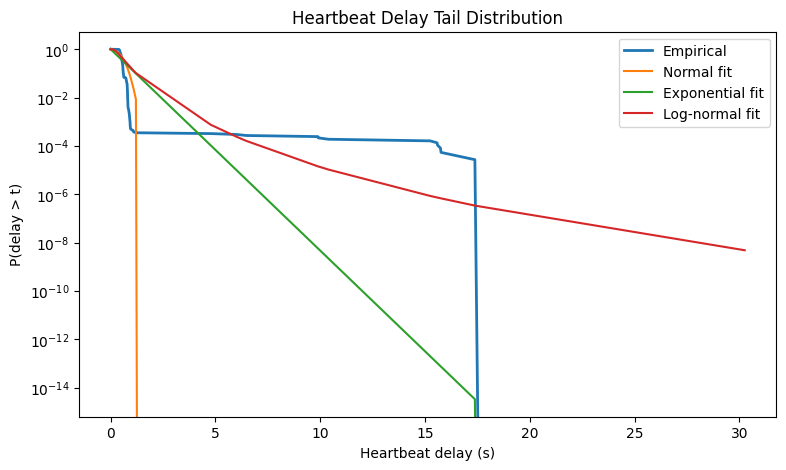

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, lognorm

data = np.array(intervals.values)

# sort delays
x = np.sort(data)

# empirical survival function
survival_emp = 1 - np.arange(1, len(x)+1)/len(x)

# --- Fit distributions ---

# Normal
mu_n, sigma_n = norm.fit(data)

# Exponential
loc_e, scale_e = expon.fit(data, floc=0)

# Log-normal
shape_l, loc_l, scale_l = lognorm.fit(data, floc=0)

# --- Compute survival curves ---

survival_norm = 1 - norm.cdf(x, mu_n, sigma_n)
survival_exp = 1 - expon.cdf(x, loc_e, scale_e)
survival_logn = 1 - lognorm.cdf(x, shape_l, loc_l, scale_l)

# --- Plot ---
plt.figure(figsize=(9,5))

plt.plot(x, survival_emp, label="Empirical", linewidth=2)
plt.plot(x, survival_norm, label="Normal fit")
plt.plot(x, survival_exp, label="Exponential fit")
plt.plot(x, survival_logn, label="Log-normal fit")

plt.yscale("log")

plt.xlabel("Heartbeat delay (s)")
plt.ylabel("P(delay > t)")
plt.title("Heartbeat Delay Tail Distribution")

plt.legend()
plt.show()

In [85]:
runtime_hours = (times[-1] - times[0]) / 3600

T_values = [0.75, 1.0, 1.5, 2.0]  # seconds

TRIALS = 50

results_timeout = []

for T in T_values:

    total = 0

    for _ in range(TRIALS):

        elections = 0

        for Δ in intervals:

            τ = np.random.uniform(T, 2*T)

            if Δ > τ:
                elections += 1

        total += elections

    avg_elections = total / TRIALS
    elections_per_hour = avg_elections / runtime_hours

    results_timeout.append((T, elections_per_hour))

timeout_df = pd.DataFrame(results_timeout,
                          columns=["base_timeout_T",
                                   "elections_per_hour"])

timeout_df

,base_timeout_T,elections_per_hour
0,0.75,24.969716
1,1.00,2.532350
2,1.50,2.420629
3,2.00,2.420629


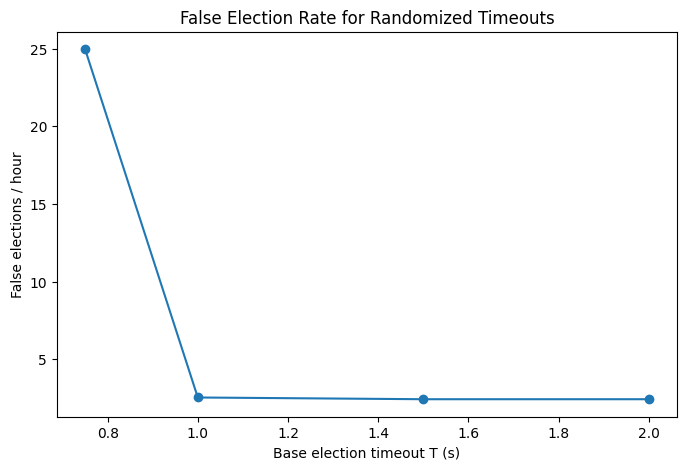

In [89]:
plt.plot(timeout_df["base_timeout_T"],
         timeout_df["elections_per_hour"],
         marker="o")

# plt.yscale("log")

plt.xlabel("Base election timeout T (s)")
plt.ylabel("False elections / hour")
plt.title("False Election Rate for Randomized Timeouts")

plt.show()

Fitted parameters:
Normal μ,σ: 0.5214107719620116 0.28672462483422834
Exponential mean: 0.5214107719620116
Lognormal shape,scale: 0.7206077616512682 0.4849088927295449


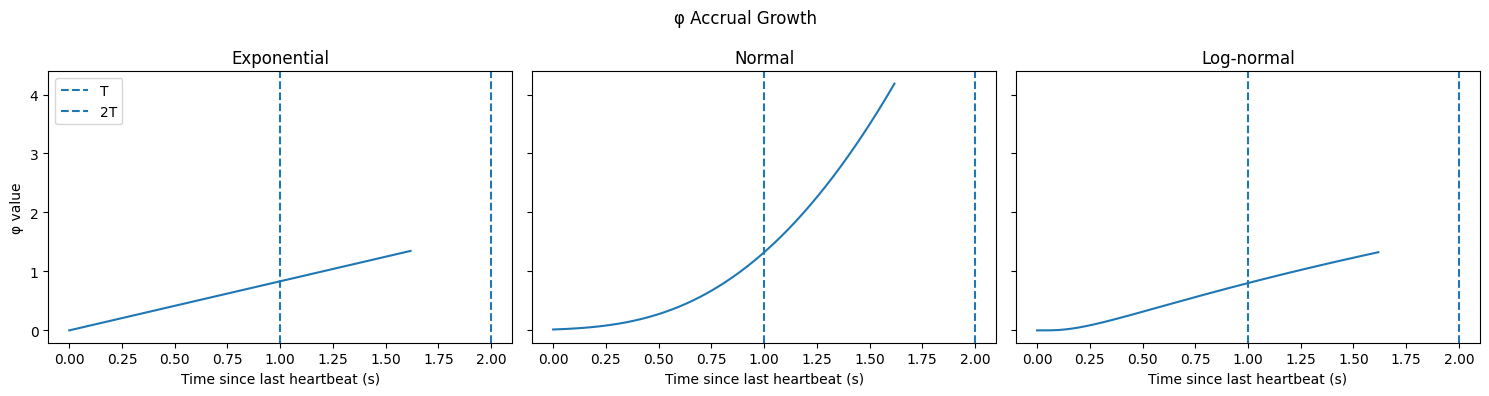

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, expon

# --- Fit distributions to collected data ---
data = np.array(intervals.values)

# Normal
mu_n, sigma_n = norm.fit(data)

# Exponential
loc_e, scale_e = expon.fit(data, floc=0)   # scale = mean

# Log-normal
shape_l, loc_l, scale_l = lognorm.fit(data, floc=0)

print("Fitted parameters:")
print("Normal μ,σ:", mu_n, sigma_n)
print("Exponential mean:", scale_e)
print("Lognormal shape,scale:", shape_l, scale_l)

# --- Time axis ---
t_max = max(3*mu_n, np.percentile(data, 99)*2)
t = np.linspace(0, t_max, 500)

# --- φ calculations ---
# Exponential
prob_exp = 1 - expon.cdf(t, loc_e, scale_e)
prob_exp = np.maximum(prob_exp, 1e-12)
phi_exp = -np.log10(prob_exp)

# Normal
prob_norm = 1 - norm.cdf(t, mu_n, sigma_n)
prob_norm = np.maximum(prob_norm, 1e-12)
phi_norm = -np.log10(prob_norm)

# Log-normal
prob_logn = 1 - lognorm.cdf(t, shape_l, loc_l, scale_l)
prob_logn = np.maximum(prob_logn, 1e-12)
phi_logn = -np.log10(prob_logn)

# --- Election timeout example ---
T = 1.0   # change if you want

# --- Plot ---
fig, axes = plt.subplots(1,3, figsize=(15,4), sharey=True)

titles = [
    "Exponential",
    "Normal",
    "Log-normal"
]

phis = [phi_exp, phi_norm, phi_logn]

for ax, phi, title in zip(axes, phis, titles):

    ax.plot(t, phi)

    ax.axvline(T, linestyle="--", label="T")
    ax.axvline(2*T, linestyle="--", label="2T")

    ax.set_title(title)
    ax.set_xlabel("Time since last heartbeat (s)")

axes[0].set_ylabel("φ value")
axes[0].legend()

plt.suptitle("φ Accrual Growth")
plt.tight_layout()
plt.show()